# **Simulation des données articielles selon la norme *NF EN ISE 14125***

L'objectif de ce notebook est de généré des fichiers `.csv` de données exploitables par un modèle de machine learning. Ce notebook se base sur une norme ISO citée dans le titre.

Nous nous basons ici sur un essai en flexion 3 points.

Lors de cet essai on impose deux valeurs de déformation :
*   $ϵ_1 = 0.0005$
*   $\epsilon_2 = 0.0025$

Ainsi le module de flexion est calculé après deux essais à ces deux valeurs de déformation en notant l'effort nécessaire pour atteindre cette déformation :

$$E = \frac{\sigma_2 - \sigma_1}{\epsilon_2 - \epsilon_1}$$

où la valeur de la contrainte $\sigma_i$ est déterminée par :
$$\sigma_i = \frac{3F_{i}d}{2le^2}$$
avec $l$ la largeur de l'éprouvette.

Pour cet simulation, nous prendrons comme valeur de référence le module d'Young de l'acier S235 : $E = 210\ 000\ \text{MPa}$. Ainsi nos valeurs seront bruitées autour de cette zone pour les éprouvettes consiédrées comme parfaites, et écartées pour les autres.

Nous choisissons de réaliser une simulation pour $N=1\ 000$ éprouvettes.

In [25]:
import pandas as pd;
import matplotlib.pyplot as plt;
import numpy as np;

N = 1000  # Nombre de points

module_ref = 210000

Nous choisissons les dimensions des éprouvettes ainsi que la distance inter-appui par loi uniforme afin de ne pas avoir strictement les mêmes éprouvettes.

\
La distance inter-appui est choisie au moins 15 fois supérieure à l'épaisseur des éprouvettes.
On impose également les valeurs des déformations.

In [26]:
largeur_eprouvette = np.random.uniform(5, 7, N)
epaisseur = np.random.uniform(1, 1.5, N)

distance_inter_appui = np.random.randint(25, 30, N)

e1 = 0.0005
e2 = 0.0025

epsilon1 = np.array([e1] * N)
epsilon2 = np.array([e2] * N)

Ensuite, nous venons générer les efforts de manière intelligente et contrôlée. En réinjectant l'expression de la contrainte, le module d'Young s'écrit :
$$E = \frac{\sigma_2 - \sigma_1}{\epsilon_2 - \epsilon_1} = \frac{\frac{3F_{2}d}{2le^2} - \frac{3F_{1}d}{2le^2}}{\epsilon_2 - \epsilon_1} = \frac{3d}{2le^2(ϵ_2 - ϵ_1)} \times (F_2 - F_1)$$

Le terme $\frac{3d}{2le^2(ϵ_2 - ϵ_1)}$ est déterminé par les caractéristiques de l'éprouvette et dde l'essai, il ne dépend donc pas de l'état d'endommagement du matériau. On note alors cette constante $k = \frac{3d}{2le^2(ϵ_2 - ϵ_1)}$.

Ainsi le module s'écrit : $$E=k \times ΔF$$

Afin d'avoir un module qui correspond au module de référence, nous déterminons $ΔF$ en fonction de $E$ et de $k$, en y ajoutant un bruit artificiel. Ensuite calcule les efforts associés :
$$F_2=1.1\timesΔF\ \text{et}\ F_1=0.1 \times \Delta F\ ⇒\ F_2 - F_1 = 1.1 \Delta F - 0.1\Delta F = \Delta F$$

In [27]:
k = (3 * distance_inter_appui) / (2 * largeur_eprouvette * epaisseur**2 * (epsilon2-epsilon1))

deltaF = module_ref  / k  + np.random.uniform(-20,10);

effort1 = deltaF*0.1
effort2 = deltaF*1.1

A présent, toutes les éprouvettes possèdent un module proches. Pour la suite nous souhaitons avoir 3 groupes d'éprouvettes classées par module :
*   Éprouvette "Parfaite : module proche du module de référence, avec une probabilité de $0.34$
*   Éprouvette "Acceptable" : module autour de $70\%$ du module de référence, avec une probabilité de $0.33$
*   Eprouvette "À jeter" : module autour de $20\%$ du module de référence, avec une probabilité de $0.33$



In [28]:
for i in range(N) :

  p = np.random.uniform(0,1)

  #Éprouvettes à jeter
  if p>0.67 :
    effort1[i] = effort1[i]*0.2
    effort2[i] = effort2[i]*0.2

  #Éprouvettes acceptables
  if p>0.34 and p<=0.67 :
    effort1[i] = effort1[i]*0.7
    effort2[i] = effort2[i]*0.7

Ensuite nous calculons la flèche $$\delta = \frac{ϵd^2}{6e}$$ pour chaque essai et chaque déformation imposée.

Nous déterminons également les contraintes, ainsi que le module d'Young final.

In [29]:
# Flèches
delta1 = (epsilon1 * distance_inter_appui**2) / (6 * epaisseur)
delta2 = (epsilon2 * distance_inter_appui**2) / (6 * epaisseur)

# Contraintes
sigma1 = (3 * effort1 * distance_inter_appui) / (2 * largeur_eprouvette * epaisseur**2)
sigma2 = (3 * effort2 * distance_inter_appui) / (2 * largeur_eprouvette * epaisseur**2)

# Module
E = (sigma2 - sigma1) / (epsilon2 - epsilon1)

Enfin, nous créons un `dataFrame` pour stocker les données avec un nom et un tableau de valeurs. Puis ce `dataFrame` permet de générer un fichier `.csv`.



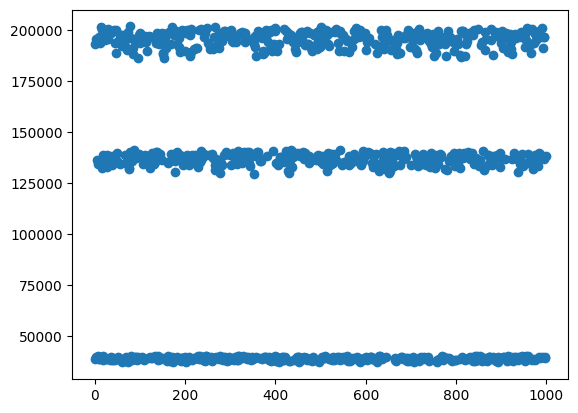

In [30]:
#Création du dataFrame
data = {
        'Largeur eprouvette': largeur_eprouvette,
        'Epaisseur': epaisseur,
        'Distance inter-appui': distance_inter_appui,
        'epsilon1': epsilon1,
        'epsilon2': epsilon2,
        'delta1': delta1,
        'delta2': delta2,
        'effort1': effort1,
        'effort2': effort2,
        'sigma1': sigma1,
        'sigma2': sigma2,
        'Module E': E,
}

df = pd.DataFrame(data)

#fichier indice 2 afin d'en créer un second et conserver le 1
filename = 'data/simulation_flexion3pts_final_2.csv'
df.to_csv(filename, index=False, encoding='utf-8')

#Affichage du module de chaque éprouvette pour analyse
plt.figure()
plt.scatter(df.index,df['Module E'])

